In [10]:
import os
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
    average_precision_score
)
import matplotlib.pyplot as plt


base = r"C:\Users\makis\ember_data\win64_clean"
dim = 2568
Random_State = 13

X_train = np.memmap(os.path.join(base, "X_train.dat"), dtype=np.float32, mode="r").reshape(-1, dim)
y_train = np.memmap(os.path.join(base, "y_train.dat"), dtype=np.int32, mode="r")

X_test  = np.memmap(os.path.join(base, "X_test.dat"),  dtype=np.float32, mode="r").reshape(-1, dim)
y_test  = np.memmap(os.path.join(base, "y_test.dat"),  dtype=np.int32, mode="r")

print(
    "Train rows:", X_train.shape[0],
    ", Train features:", X_train.shape[1],
    ", Test rows:", X_test.shape[0],
    ", Test features:", X_test.shape[1]
)

print("Train label counts:", dict(pd.Series(y_train).value_counts()))
print("Test  label counts:", dict(pd.Series(y_test).value_counts()))



Train rows: 520000 , Train features: 2568 , Test rows: 120000 , Test features: 2568
Train label counts: {0: 260000, 1: 260000}
Test  label counts: {0: 60000, 1: 60000}



Training baseline RandomForest...
Training time: 768.20 seconds
OOB Accuracy : 0.9857

=== RANDOM FOREST BASELINE (TEST SET) ===
Accuracy  : 0.9792
Precision : 0.9828
Recall    : 0.9755
F1 score  : 0.9791
Log loss  : 0.1099
ROC AUC   : 0.9969
PR AUC    : 0.9965

Confusion Matrix [[TN FP],[FN TP]]:
[[58978  1022]
 [ 1472 58528]]


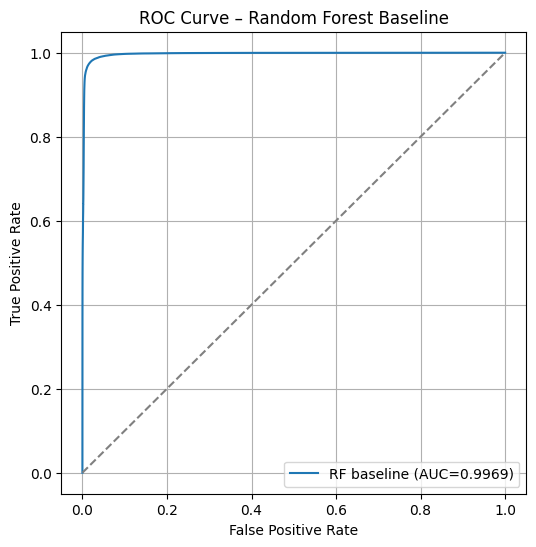

In [18]:
#baseline model
rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        n_jobs=-1,
        random_state=Random_State,
        class_weight= None,
        bootstrap=True,          
        oob_score=True,
    )


print("\nTraining baseline RandomForest...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
end_time = time.perf_counter()
train_time = end_time-start_time


# Predict on TEST set
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)


# Metrics

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)


# Output
print(f"Training time: {train_time:.2f} seconds")
print(f"OOB Accuracy : {rf.oob_score_:.4f}")
print("\n=== RANDOM FOREST BASELINE (TEST SET) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 score  : {f1:.4f}")
print(f"Log loss  : {ll:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")


print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)


#Optional ROC plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF baseline (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest Baseline")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
#Testing sample size
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

results = []

SUBSET_SIZES = [2000, 5000, 10000, 20000, 40000, 60000, 80000, 120000, 180000, 240000, 300000, 400000, 500000]


np.random.seed(Random_State)

for SUBSET_SIZE in SUBSET_SIZES:
    print("\n=== SUBSET SIZE:", SUBSET_SIZE, "===")

    half = SUBSET_SIZE // 2

    sel_0 = np.random.choice(idx_0, half, replace=False)
    sel_1 = np.random.choice(idx_1, half, replace=False)

    subset_idx = np.concatenate([sel_0, sel_1])
    np.random.shuffle(subset_idx)

    X_sub = X_train[subset_idx]
    y_sub = y_train[subset_idx]

    # train / validation split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_sub, y_sub,
        test_size=0.1,
        stratify=y_sub,
        random_state=40
    )

    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        n_jobs=-1,
        random_state=Random_State,
        class_weight="balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )

    #training time 
    t0 = time.perf_counter()
    rf.fit(X_tr, y_tr)
    t1 = time.perf_counter()
    train_time = t1 - t0

    oob_acc = rf.oob_score_                        
    oob_proba = rf.oob_decision_function_[:, 1]     
    oob_roc = roc_auc_score(y_tr, oob_proba)        
    oob_pr  = average_precision_score(y_tr, oob_proba)  

    #predictions
    y_val_proba = rf.predict_proba(X_val)[:, 1]
    y_val_pred  = (y_val_proba >= 0.5).astype(int)

    #metrics
    acc  = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec  = recall_score(y_val, y_val_pred, zero_division=0)
    f1   = f1_score(y_val, y_val_pred, zero_division=0)
    ll   = log_loss(y_val, y_val_proba)
    roc  = roc_auc_score(y_val, y_val_proba)
    pr   = average_precision_score(y_val, y_val_proba)
  

    results.append({
        "subset_size": SUBSET_SIZE,
        "train_size": X_tr.shape[0],
        "val_size": X_val.shape[0],
        "train_time_s": train_time,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "log_loss": ll,
        "roc_auc": roc,
        "pr_auc": pr,
        "oob_accuracy": oob_acc,
        "oob_roc_auc": oob_roc,
        "oob_pr_auc": oob_pr
    })

results_df = pd.DataFrame(results)
results_df


=== SUBSET SIZE: 2000 ===

=== SUBSET SIZE: 5000 ===

=== SUBSET SIZE: 10000 ===

=== SUBSET SIZE: 20000 ===

=== SUBSET SIZE: 40000 ===

=== SUBSET SIZE: 60000 ===

=== SUBSET SIZE: 80000 ===

=== SUBSET SIZE: 120000 ===

=== SUBSET SIZE: 180000 ===

=== SUBSET SIZE: 240000 ===

=== SUBSET SIZE: 300000 ===

=== SUBSET SIZE: 400000 ===

=== SUBSET SIZE: 500000 ===


,subset_size,train_size,val_size,train_time_s,accuracy,precision,recall,f1,log_loss,roc_auc,pr_auc,oob_accuracy,oob_roc_auc,oob_pr_auc
0,2000,1800,200,0.562544,0.940000,0.940000,0.940000,0.940000,0.182112,0.984700,0.986951,0.928889,0.980397,0.982269
1,5000,4500,500,1.391863,0.940000,0.958333,0.920000,0.938776,0.180605,0.985672,0.985904,0.943778,0.987490,0.988414
2,10000,9000,1000,3.369051,0.948000,0.949799,0.946000,0.947896,0.159673,0.988826,0.989694,0.951444,0.989443,0.990731
3,20000,18000,2000,8.852823,0.961000,0.963783,0.958000,0.960883,0.128210,0.993008,0.993986,0.960778,0.993345,0.993807
4,40000,36000,4000,20.490093,0.972500,0.979209,0.965500,0.972306,0.102828,0.995720,0.996046,0.967528,0.994813,0.995163
5,60000,54000,6000,35.056314,0.973667,0.982022,0.965000,0.973436,0.099454,0.996288,0.996339,0.969296,0.995354,0.995721
6,80000,72000,8000,50.637161,0.975375,0.981514,0.969000,0.975217,0.098034,0.996735,0.996834,0.973014,0.996146,0.996376
7,120000,108000,12000,88.215785,0.973500,0.978283,0.968500,0.973367,0.096763,0.996324,0.996381,0.976537,0.996953,0.997109
8,180000,162000,18000,160.242954,0.981833,0.985665,0.977889,0.981761,0.074195,0.998061,0.998045,0.978932,0.997577,0.997681
9,240000,216000,24000,228.993315,0.982500,0.986718,0.978167,0.982424,0.075732,0.997997,0.997919,0.980468,0.997868,0.997918


In [3]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

SUBSET_SIZE = 50000   
N_ITER = 50

# Balanced subset (50/50)

half = SUBSET_SIZE // 2
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

np.random.seed(Random_State)
sel_0 = np.random.choice(idx_0, half, replace=False)
sel_1 = np.random.choice(idx_1, half, replace=False)

subset_idx = np.concatenate([sel_0, sel_1])
np.random.shuffle(subset_idx)

X_sub = X_train[subset_idx]
y_sub = y_train[subset_idx]

print("Subset rows:", X_sub.shape[0], "Label counts:", dict(pd.Series(y_sub).value_counts()))


# Model + search space

rf = RandomForestClassifier(
    n_jobs=-1,                 
    random_state=Random_State,
    bootstrap = True
)

param_dist = {
    
    "n_estimators": [100, 200, 300], 
    "criterion": ["gini", "entropy"],
    "max_depth": [30, 45, None],
    
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.1], 
    
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=Random_State)


scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring=scoring,
    refit="pr_auc",            
    cv=cv,
    verbose=2,
    random_state=Random_State,
    n_jobs=1,                  
    return_train_score=False
)

print("\nRunning RandomizedSearchCV (scoring PR AUC + ROC AUC)...")
t_search0 = time.perf_counter()
search.fit(X_sub, y_sub)
t_search1 = time.perf_counter()
print(f"\nTotal search wall time: {t_search1 - t_search0:.2f} seconds")

print("\n=== BEST RESULT (by PR AUC) ===")
print("Best score (PR AUC):", search.best_score_)
print("Best params:", search.best_params_)


results = pd.DataFrame(search.cv_results_)#contains metrics,rank,time spent fitting,params

summary_cols = [
    "rank_test_pr_auc",
    "mean_test_pr_auc",
    "mean_test_roc_auc",
    "mean_fit_time",
    "std_fit_time",
    "params",
]

summary = results[summary_cols].copy()
summary["approx_total_fit_time_all_folds"] = summary["mean_fit_time"] * cv.get_n_splits()

# Sort by PR AUC (best first)
summary = summary.sort_values("mean_test_pr_auc", ascending=False).reset_index(drop=True)#sort values based on pr_auc

print("\n=== TOP 10 CANDIDATES (sorted by PR AUC) ===")
print(summary.head(10).to_string(index=False))

# Save full table to disk so you can analyze later
out_csv = os.path.join(base, "rf_randomsearch_pr_roc_timing_results.csv")
summary.to_csv(out_csv, index=False)
print(f"\nSaved per-parameter-set results to: {out_csv}")

Subset rows: 50000 Label counts: {0: 25000, 1: 25000}

Running RandomizedSearchCV (scoring PR AUC + ROC AUC)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  15.2s
[CV] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  15.3s
[CV] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  14.5s
[CV] END criterion=entropy, max_depth=None, max_features=0.1, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 1.4min
[CV] END criterion=entropy, max_depth=None, max_features=0.1, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 1.3min
[CV] END criterion=entropy, max_depth=None, max_features=0.1, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=

'# Final training on FULL TRAIN \nrf_final = RandomForestClassifier(\n    **search.best_params_,\n    n_jobs=-1,\n    random_state=Random_State\n)\n\nt0 = time.perf_counter()\nrf_final.fit(X_train, y_train)\nt1 = time.perf_counter()\nprint(f"\nFinal training time on FULL TRAIN: {t1 - t0:.2f} seconds")'

In [7]:
#number of trees test
#model

X_full = X_train
y_full = y_train


X_sub = X_full[:260_000]
y_sub = y_full[:260_000]

X_tr = X_sub[:200_000]
y_tr = y_sub[:200_000]

X_te = X_sub[200_000:260_000]
y_te = y_sub[200_000:260_000]

print("Train size:", X_tr.shape)
print("Test size :", X_te.shape)
print("Train label counts:", dict(pd.Series(y_tr).value_counts()))
print("Test  label counts:", dict(pd.Series(y_te).value_counts()))


# 2. Loop over n_est

for n_est in [80,100,120,150,200]:
    rf = RandomForestClassifier(
        n_estimators=n_est,
        max_features="sqrt",
        n_jobs=-1,
        random_state=Random_State,
        bootstrap=True,
        oob_score=True,
        class_weight=None,
    )

    print(f"\nTraining RandomForest (n_est={n_est})")
    start = time.perf_counter()
    rf.fit(X_tr, y_tr)
    train_time = time.perf_counter() - start

    # 3. Prediction
    y_proba = rf.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    
    # 4. Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    ll      = log_loss(y_te, y_proba)
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc  = average_precision_score(y_te, y_proba)

    cm = confusion_matrix(y_te, y_pred)
    fpr, tpr, thresholds = roc_curve(y_te, y_proba)

    
    # 5. Output
    
    print(f"Training time: {train_time:.2f} seconds")
    print(f"OOB Accuracy : {rf.oob_score_:.4f}")

    print("\n=== RANDOM FOREST (TEST SET) ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 score  : {f1:.4f}")
    print(f"Log loss  : {ll:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    print("\nConfusion Matrix [[TN FP],[FN TP]]:")
    print(cm)



Train size: (200000, 2568)
Test size : (60000, 2568)
Train label counts: {0: 100000, 1: 100000}
Test  label counts: {0: 30000, 1: 30000}

Training RandomForest (n_est=80)
Training time: 186.52 seconds
OOB Accuracy : 0.9855

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9729
Precision : 0.9848
Recall    : 0.9606
F1 score  : 0.9726
Log loss  : 0.1178
ROC AUC   : 0.9954
PR AUC    : 0.9957

Confusion Matrix [[TN FP],[FN TP]]:
[[29556   444]
 [ 1181 28819]]

Training RandomForest (n_est=100)
Training time: 220.21 seconds
OOB Accuracy : 0.9858

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9733
Precision : 0.9848
Recall    : 0.9615
F1 score  : 0.9730
Log loss  : 0.1171
ROC AUC   : 0.9954
PR AUC    : 0.9958

Confusion Matrix [[TN FP],[FN TP]]:
[[29554   446]
 [ 1154 28846]]

Training RandomForest (n_est=120)
Training time: 255.32 seconds
OOB Accuracy : 0.9858

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9732
Precision : 0.9848
Recall    : 0.9614
F1 score  : 0.9729
Log loss  : 0.1139
ROC 

In [2]:
#number of features per split
#model

X_full = X_train
y_full = y_train


X_sub = X_full[:360_000]
y_sub = y_full[:360_000]

X_tr = X_sub[:300_000]
y_tr = y_sub[:300_000]

X_te = X_sub[300_000:360_000]
y_te = y_sub[300_000:360_000]

print("Train size:", X_tr.shape)
print("Test size :", X_te.shape)
print("Train label counts:", dict(pd.Series(y_tr).value_counts()))
print("Test  label counts:", dict(pd.Series(y_te).value_counts()))


# 2. Loop over max_features

for ft in ["sqrt", 0.05, 0.1]:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=ft,
        n_jobs=-1,
        random_state=Random_State,
        bootstrap=True,
        oob_score=True,
        class_weight=None,
    )

    print(f"\nTraining RandomForest (max_features={ft})")
    start = time.perf_counter()
    rf.fit(X_tr, y_tr)
    train_time = time.perf_counter() - start

    # 3. Prediction
    y_proba = rf.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    
    # 4. Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    ll      = log_loss(y_te, y_proba)
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc  = average_precision_score(y_te, y_proba)

    cm = confusion_matrix(y_te, y_pred)
    fpr, tpr, thresholds = roc_curve(y_te, y_proba)

    
    # 5. Output
    
    print(f"Training time: {train_time:.2f} seconds")
    print(f"OOB Accuracy : {rf.oob_score_:.4f}")

    print("\n=== RANDOM FOREST (TEST SET) ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 score  : {f1:.4f}")
    print(f"Log loss  : {ll:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    print("\nConfusion Matrix [[TN FP],[FN TP]]:")
    print(cm)


Train size: (300000, 2568)
Test size : (60000, 2568)
Train label counts: {0: 150000, 1: 150000}
Test  label counts: {1: 30000, 0: 30000}

Training RandomForest (max_features=sqrt)
Training time: 364.56 seconds
OOB Accuracy : 0.9850

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9773
Precision : 0.9795
Recall    : 0.9750
F1 score  : 0.9772
Log loss  : 0.0844
ROC AUC   : 0.9973
PR AUC    : 0.9972

Confusion Matrix [[TN FP],[FN TP]]:
[[29388   612]
 [  750 29250]]

Training RandomForest (max_features=0.05)
Training time: 1147.07 seconds
OOB Accuracy : 0.9862

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9792
Precision : 0.9791
Recall    : 0.9792
F1 score  : 0.9792
Log loss  : 0.0737
ROC AUC   : 0.9976
PR AUC    : 0.9975

Confusion Matrix [[TN FP],[FN TP]]:
[[29374   626]
 [  624 29376]]

Training RandomForest (max_features=0.1)
Training time: 2595.14 seconds
OOB Accuracy : 0.9867

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9795
Precision : 0.9797
Recall    : 0.9794
F1 score  : 0.97

In [4]:
# 2. Loop over min_sample_leafs

for leaf in [2,3,5,10]:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf = leaf,
        n_jobs=-1,
        random_state=Random_State,
        bootstrap=True,
        oob_score=True,
        class_weight=None,
    )

    print(f"\nTraining RandomForest (min_sample_leaf={leaf})")
    start = time.perf_counter()
    rf.fit(X_tr, y_tr)
    train_time = time.perf_counter() - start

    # 3. Prediction
    y_proba = rf.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    
    # 4. Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    ll      = log_loss(y_te, y_proba)
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc  = average_precision_score(y_te, y_proba)

    cm = confusion_matrix(y_te, y_pred)
    fpr, tpr, thresholds = roc_curve(y_te, y_proba)

    
    # 5. Output
    
    print(f"Training time: {train_time:.2f} seconds")
    print(f"OOB Accuracy : {rf.oob_score_:.4f}")

    print("\n=== RANDOM FOREST (TEST SET) ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 score  : {f1:.4f}")
    print(f"Log loss  : {ll:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    print("\nConfusion Matrix [[TN FP],[FN TP]]:")
    print(cm)


Training RandomForest (min_sample_leaf=2)
Training time: 350.32 seconds
OOB Accuracy : 0.9845

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9766
Precision : 0.9791
Recall    : 0.9739
F1 score  : 0.9765
Log loss  : 0.0842
ROC AUC   : 0.9972
PR AUC    : 0.9972

Confusion Matrix [[TN FP],[FN TP]]:
[[29377   623]
 [  783 29217]]

Training RandomForest (min_sample_leaf=3)
Training time: 333.83 seconds
OOB Accuracy : 0.9835

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9752
Precision : 0.9781
Recall    : 0.9721
F1 score  : 0.9751
Log loss  : 0.0868
ROC AUC   : 0.9970
PR AUC    : 0.9971

Confusion Matrix [[TN FP],[FN TP]]:
[[29346   654]
 [  836 29164]]

Training RandomForest (min_sample_leaf=5)
Training time: 320.55 seconds
OOB Accuracy : 0.9822

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9737
Precision : 0.9773
Recall    : 0.9699
F1 score  : 0.9736
Log loss  : 0.0903
ROC AUC   : 0.9967
PR AUC    : 0.9968

Confusion Matrix [[TN FP],[FN TP]]:
[[29323   677]
 [  902 29098]]

Training 

In [5]:
# 2. Loop over max_depth

for md in [15,25,35,45,60,None]:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        max_depth=md,
        n_jobs=-1,
        random_state=Random_State,
        bootstrap=True,
        oob_score=True,
        class_weight=None,
    )

    print(f"\nTraining RandomForest (max_depth={md})")
    start = time.perf_counter()
    rf.fit(X_tr, y_tr)
    train_time = time.perf_counter() - start

    # 3. Prediction
    y_proba = rf.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    
    # 4. Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    ll      = log_loss(y_te, y_proba)
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc  = average_precision_score(y_te, y_proba)

    cm = confusion_matrix(y_te, y_pred)
    fpr, tpr, thresholds = roc_curve(y_te, y_proba)

    
    # 5. Output
    
    print(f"Training time: {train_time:.2f} seconds")
    print(f"OOB Accuracy : {rf.oob_score_:.4f}")

    print("\n=== RANDOM FOREST (TEST SET) ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 score  : {f1:.4f}")
    print(f"Log loss  : {ll:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    print("\nConfusion Matrix [[TN FP],[FN TP]]:")
    print(cm)


Training RandomForest (max_depth=15)
Training time: 205.52 seconds
OOB Accuracy : 0.9772

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9674
Precision : 0.9691
Recall    : 0.9656
F1 score  : 0.9674
Log loss  : 0.1076
ROC AUC   : 0.9951
PR AUC    : 0.9953

Confusion Matrix [[TN FP],[FN TP]]:
[[29076   924]
 [ 1031 28969]]

Training RandomForest (max_depth=25)
Training time: 269.94 seconds
OOB Accuracy : 0.9838

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9755
Precision : 0.9775
Recall    : 0.9734
F1 score  : 0.9754
Log loss  : 0.0813
ROC AUC   : 0.9969
PR AUC    : 0.9971

Confusion Matrix [[TN FP],[FN TP]]:
[[29328   672]
 [  799 29201]]

Training RandomForest (max_depth=35)
Training time: 312.64 seconds
OOB Accuracy : 0.9847

=== RANDOM FOREST (TEST SET) ===
Accuracy  : 0.9770
Precision : 0.9794
Recall    : 0.9745
F1 score  : 0.9769
Log loss  : 0.0789
ROC AUC   : 0.9972
PR AUC    : 0.9973

Confusion Matrix [[TN FP],[FN TP]]:
[[29384   616]
 [  764 29236]]

Training RandomForest (m


Training tuned RandomForest...
Training time: 1915.74 seconds
OOB Accuracy : 0.9866

=== RANDOM FOREST tuned (TEST SET) ===
Accuracy  : 0.9807
Precision : 0.9828
Recall    : 0.9784
F1 score  : 0.9806
Log loss  : 0.0922
ROC AUC   : 0.9972
PR AUC    : 0.9969

Confusion Matrix [[TN FP],[FN TP]]:
[[58972  1028]
 [ 1294 58706]]


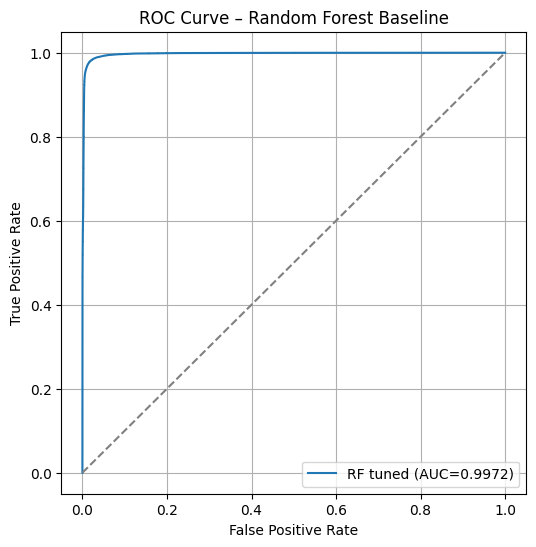

In [9]:
#tuned model
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=0.05,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=45,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )


print("\nTraining tuned RandomForest...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
end_time = time.perf_counter()
train_time = end_time-start_time


# Predict on TEST set
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)


# Metrics

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)


# Output
print(f"Training time: {train_time:.2f} seconds")
print(f"OOB Accuracy : {rf.oob_score_:.4f}")
print("\n=== RANDOM FOREST tuned (TEST SET) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 score  : {f1:.4f}")
print(f"Log loss  : {ll:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")


print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)


#Optional ROC plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF tuned (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest Baseline")
plt.legend()
plt.grid(True)
plt.show()


Training tuned RandomForest...
Training time: 4805.11 seconds
OOB Accuracy : 0.9875

=== RANDOM FOREST tuned (TEST SET) ===
Accuracy  : 0.9804
Precision : 0.9828
Recall    : 0.9778
F1 score  : 0.9803
Log loss  : 0.0720
ROC AUC   : 0.9979
PR AUC    : 0.9978

Confusion Matrix [[TN FP],[FN TP]]:
[[58976  1024]
 [ 1333 58667]]


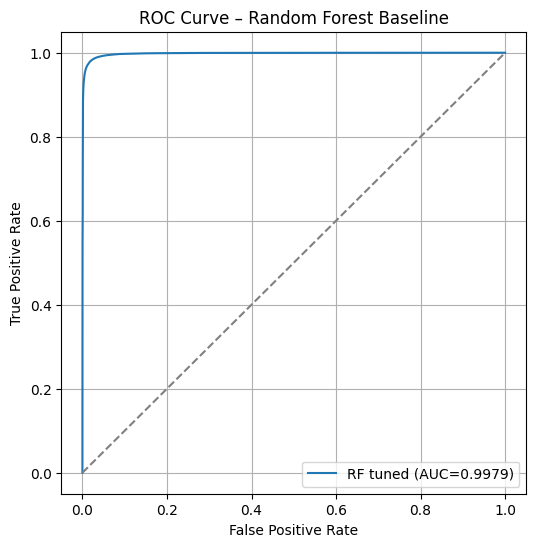

In [11]:
#tuned model
rf = RandomForestClassifier(
        n_estimators=300,
        max_features=0.1,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=None,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
        criterion= "entropy"
    )


print("\nTraining tuned RandomForest...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
end_time = time.perf_counter()
train_time = end_time-start_time


# Predict on TEST set
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)


# Metrics

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)


# Output
print(f"Training time: {train_time:.2f} seconds")
print(f"OOB Accuracy : {rf.oob_score_:.4f}")
print("\n=== RANDOM FOREST tuned (TEST SET) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 score  : {f1:.4f}")
print(f"Log loss  : {ll:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")


print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)


#Optional ROC plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF tuned (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest Baseline")
plt.legend()
plt.grid(True)
plt.show()

Train rows: 520000 , Train features: 2568 , Test rows: 120000 , Test features: 2568
Train label counts: {0: 260000, 1: 260000}
Test  label counts: {0: 60000, 1: 60000}

Using only ByteHistogram + ByteEntropyHistogram features: cols [7:519)
New Train shape: (520000, 512) New Test shape: (120000, 512)

Training RandomForest (histogram + byteentropy only)...

Training time: 531.98 seconds

=== RANDOM FOREST (ByteHistogram + ByteEntropyHistogram ONLY) (TEST SET) ===
Accuracy  : 0.957475
Precision : 0.976396
Recall    : 0.937617
F1 score  : 0.956613
Log loss  : 0.160943
ROC AUC   : 0.991552
PR AUC    : 0.991226

Confusion Matrix [[TN FP],[FN TP]]:
[[58640  1360]
 [ 3743 56257]]


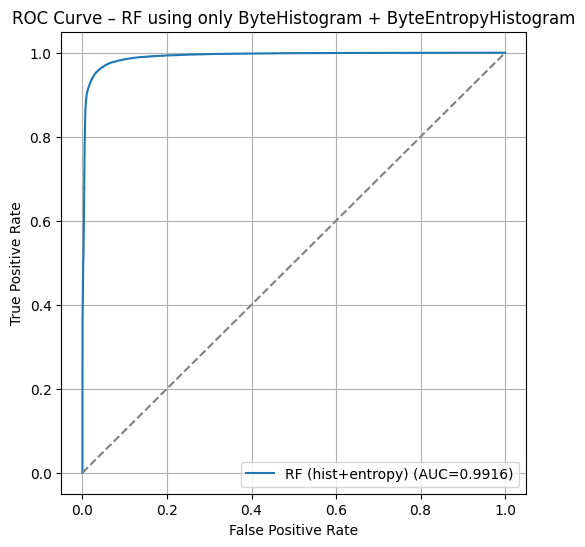

In [12]:
#bytehistogram and byteentropyhistogram features only
import os
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
    average_precision_score
)
import matplotlib.pyplot as plt



# Paths / settings

base = r"C:\Users\makis\ember_data\win64_clean"
FULL_DIM = 2568
RANDOM_STATE = 13


# Load full memmaps

X_train_full = np.memmap(os.path.join(base, "X_train.dat"), dtype=np.float32, mode="r").reshape(-1, dim)
y_train = np.memmap(os.path.join(base, "y_train.dat"), dtype=np.int32, mode="r")

X_test_full  = np.memmap(os.path.join(base, "X_test.dat"),  dtype=np.float32, mode="r").reshape(-1, dim)
y_test  = np.memmap(os.path.join(base, "y_test.dat"),  dtype=np.int32, mode="r")

print(
    "Train rows:", X_train_full.shape[0],
    ", Train features:", X_train_full.shape[1],
    ", Test rows:", X_test_full.shape[0],
    ", Test features:", X_test_full.shape[1]
)
print("Train label counts:", dict(pd.Series(y_train).value_counts()))
print("Test  label counts:", dict(pd.Series(y_test).value_counts()))


# Feature slicing(histogram + byteentropy)

GENERAL_DIM = 7
HIST_DIM = 256
ENT_DIM = 256

start = GENERAL_DIM
end = GENERAL_DIM + HIST_DIM + ENT_DIM  

X_train = X_train_full[:, start:end]
X_test = X_test_full[:, start:end]

print(f"\nUsing only ByteHistogram + ByteEntropyHistogram features: cols [{start}:{end})")
print("New Train shape:", X_train.shape, "New Test shape:", X_test.shape)


# Model 
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=0.05,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=45,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )


print("\nTraining RandomForest (histogram + byteentropy only)...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - start_time


# Predict / metrics

y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
cm = confusion_matrix(y_test, y_test_pred)

ll = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

print(f"\nTraining time: {train_time:.2f} seconds")
print("\n=== RANDOM FOREST (ByteHistogram + ByteEntropyHistogram ONLY) (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)


# ROC plot

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF (hist+entropy) (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF using only ByteHistogram + ByteEntropyHistogram")
plt.legend()
plt.grid(True)
plt.show()


Using ONLY IMPORT features: cols [994:2276)
New Train shape: (520000, 1282)
New Test shape : (120000, 1282)

Training RandomForest (IMPORT FEATURES ONLY)...

Training time: 503.10 seconds

=== RANDOM FOREST (IMPORT FEATURES ONLY) (TEST SET) ===
Accuracy  : 0.935692
Precision : 0.916246
Recall    : 0.959050
F1 score  : 0.937160
Log loss  : 0.209159
ROC AUC   : 0.981392
PR AUC    : 0.976642

Confusion Matrix [[TN FP],[FN TP]]:
[[54740  5260]
 [ 2457 57543]]


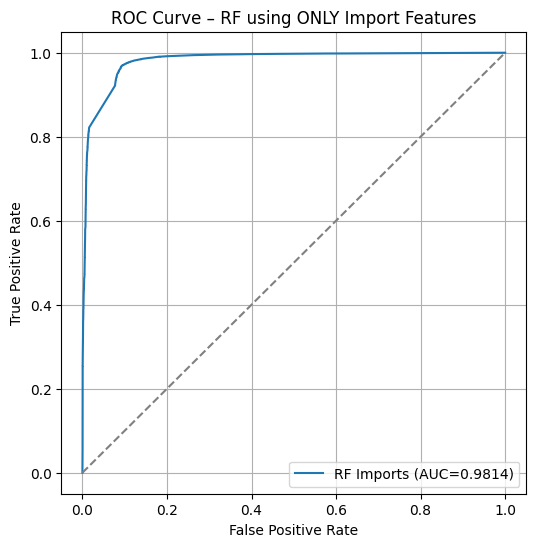

In [13]:
# IMPORT FEATURES ONLY

# General(7) + ByteHist(256) + ByteEntropy(256) + Strings(177) + HeaderFileInfo(74) + SectionInfo(224) 
IMPORT_START = 7 + 256 + 256 + 177 + 74 + 224
IMPORT_DIM = 1282
IMPORT_END = IMPORT_START + IMPORT_DIM

X_train = X_train_full[:, IMPORT_START:IMPORT_END]
X_test  = X_test_full[:, IMPORT_START:IMPORT_END]

print(f"\nUsing ONLY IMPORT features: cols [{IMPORT_START}:{IMPORT_END})")
print("New Train shape:", X_train.shape)
print("New Test shape :", X_test.shape)


# Model
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=0.05,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=45,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )

print("\nTraining RandomForest (IMPORT FEATURES ONLY)...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - start_time


# Evaluation
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
cm = confusion_matrix(y_test, y_test_pred)

ll = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

print(f"\nTraining time: {train_time:.2f} seconds")
print("\n=== RANDOM FOREST (IMPORT FEATURES ONLY) (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)


# ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF Imports (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF using ONLY Import Features")
plt.legend()
plt.grid(True)
plt.show()


Using ONLY EXPORT features: cols [2276:2405)
New Train shape: (520000, 129)
New Test shape : (120000, 129)

Training RandomForest (EXPORT FEATURES ONLY)...

Training time: 85.92 seconds

=== RANDOM FOREST (EXPORT FEATURES ONLY) (TEST SET) ===
Accuracy  : 0.851825
Precision : 0.790353
Recall    : 0.957683
F1 score  : 0.866009
Log loss  : 0.394986
ROC AUC   : 0.863470
PR AUC    : 0.789924

Confusion Matrix [[TN FP],[FN TP]]:
[[44758 15242]
 [ 2539 57461]]


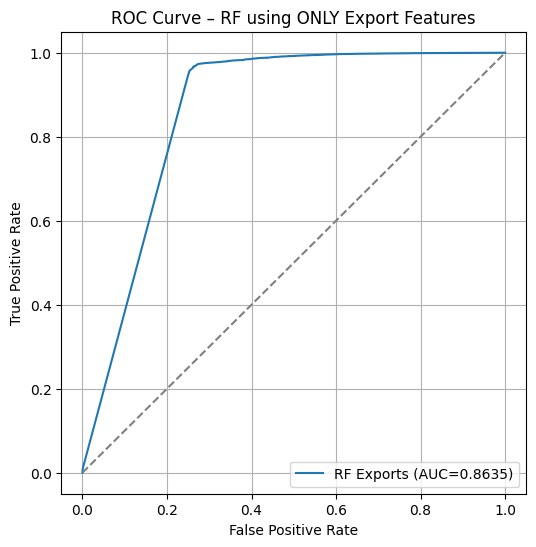

In [14]:
# EXPORT FEATURES ONLY

EXPORT_START = 7 + 256 + 256 + 177 + 74 + 224 + 1282
EXPORT_END   = EXPORT_START + 129

X_train = X_train_full[:, EXPORT_START:EXPORT_END]
X_test  = X_test_full[:,  EXPORT_START:EXPORT_END]

print(f"\nUsing ONLY EXPORT features: cols [{EXPORT_START}:{EXPORT_END})")
print("New Train shape:", X_train.shape)
print("New Test shape :", X_test.shape)

# Model
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=0.05,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=45,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )

print("\nTraining RandomForest (EXPORT FEATURES ONLY)...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# Predict on TEST set
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# Metrics
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll      = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

print(f"\nTraining time: {train_time:.2f} seconds")
print("\n=== RANDOM FOREST (EXPORT FEATURES ONLY) (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# Optional ROC plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF Exports (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF using ONLY Export Features")
plt.legend()
plt.grid(True)
plt.show()


Using ONLY Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning features: cols [2405:2568)
New Train shape: (520000, 163)
New Test shape : (120000, 163)

Training RandomForest (Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning FEATURES ONLY)...

Training time: 72.01 seconds

=== RANDOM FOREST (Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning FEATURES ONLY) (TEST SET) ===
Accuracy  : 0.971867
Precision : 0.976344
Recall    : 0.967167
F1 score  : 0.971734
Log loss  : 0.103757
ROC AUC   : 0.995367
PR AUC    : 0.995199

Confusion Matrix [[TN FP],[FN TP]]:
[[58594  1406]
 [ 1970 58030]]


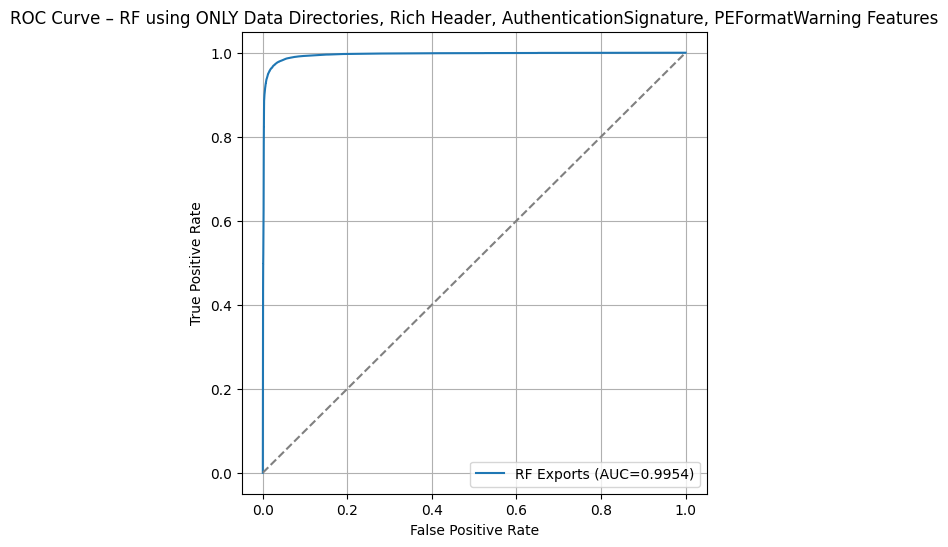

In [15]:
# Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning

EXPORT_START = 7 + 256 + 256 + 177 + 74 + 224 + 1282 + 129
EXPORT_END   = EXPORT_START + 34 + 33 + 8 + 88

X_train = X_train_full[:, EXPORT_START:EXPORT_END]
X_test  = X_test_full[:,  EXPORT_START:EXPORT_END]

print(f"\nUsing ONLY Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning features: cols [{EXPORT_START}:{EXPORT_END})")
print("New Train shape:", X_train.shape)
print("New Test shape :", X_test.shape)

# Model
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=0.05,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=45,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )

print("\nTraining RandomForest (Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning FEATURES ONLY)...")
start_time = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# Predict on TEST set
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# Metrics
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll      = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

print(f"\nTraining time: {train_time:.2f} seconds")
print("\n=== RANDOM FOREST (Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning FEATURES ONLY) (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# Optional ROC plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF Exports (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF using ONLY Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning Features")
plt.legend()
plt.grid(True)
plt.show()

Using General + Strings + Header + Section
Train shape: (520000, 482)
Test shape : (120000, 482)

Training RandomForest...

Training time: 268.06s
Accuracy  : 0.979708
Precision : 0.982612
Recall    : 0.976700
F1 score  : 0.979647
Log loss  : 0.106092
ROC AUC   : 0.996667
PR AUC    : 0.996221

Confusion Matrix [[TN FP],[FN TP]]:
[[58963  1037]
 [ 1398 58602]]


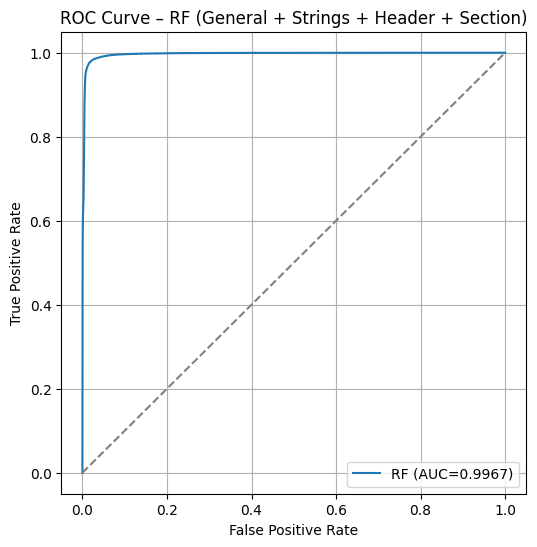

In [16]:
#GeneralFileInfo+ Strings+ HeaderInfo+ SectionInfo
GEN_START, GEN_END = 0, 7
STR_START, SEC_END = 519, 994   # Strings+Header+Section

X_train = np.hstack([ X_train_full[:, GEN_START:GEN_END], X_train_full[:, STR_START:SEC_END]])

X_test = np.hstack([ X_test_full[:, GEN_START:GEN_END], X_test_full[:, STR_START:SEC_END]])

print("Using General + Strings + Header + Section")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
assert X_train.shape[1] == X_test.shape[1]

#model
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=0.05,
        n_jobs=-1,
        random_state=Random_State,
        max_depth=45,
        class_weight= "balanced_subsample",
        bootstrap=True,          
        oob_score=True,
    )

print("\nTraining RandomForest...")
t0 = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - t0

#eval
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_pred)
ll   = log_loss(y_test, y_proba)
roc  = roc_auc_score(y_test, y_proba)
pra  = average_precision_score(y_test, y_proba)

print(f"\nTraining time: {train_time:.2f}s")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc:.6f}")
print(f"PR AUC    : {pra:.6f}")
print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF (AUC={roc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF (General + Strings + Header + Section)")
plt.legend()
plt.grid(True)
plt.show()